In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix,classification_report,roc_curve,roc_auc_score


In [2]:
DATA_PATH=Path('data/diabetes.csv')
df=pd.read_csv(DATA_PATH)
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
numeric_features=df.select_dtypes(include='number')

In [4]:
X=numeric_features.drop(['Outcome'],axis=1)
y=df['Outcome']

In [5]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [6]:
cols_to_clean = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
X_train[cols_to_clean] = X_train[cols_to_clean].replace(0, np.nan)
X_test[cols_to_clean] = X_test[cols_to_clean].replace(0, np.nan)

In [7]:
imputer = SimpleImputer(strategy='median')
X_train[cols_to_clean] = imputer.fit_transform(X_train[cols_to_clean])
X_test[cols_to_clean] = imputer.transform(X_test[cols_to_clean])

In [8]:
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)

In [9]:
test_score=[]
train_score=[]

for i in range(1,15):
    knn=KNeighborsClassifier(i)
    knn.fit(X_train_scaled,y_train)

    train_score.append(knn.score(X_train_scaled,y_train))
    test_score.append(knn.score(X_test_scaled,y_test))

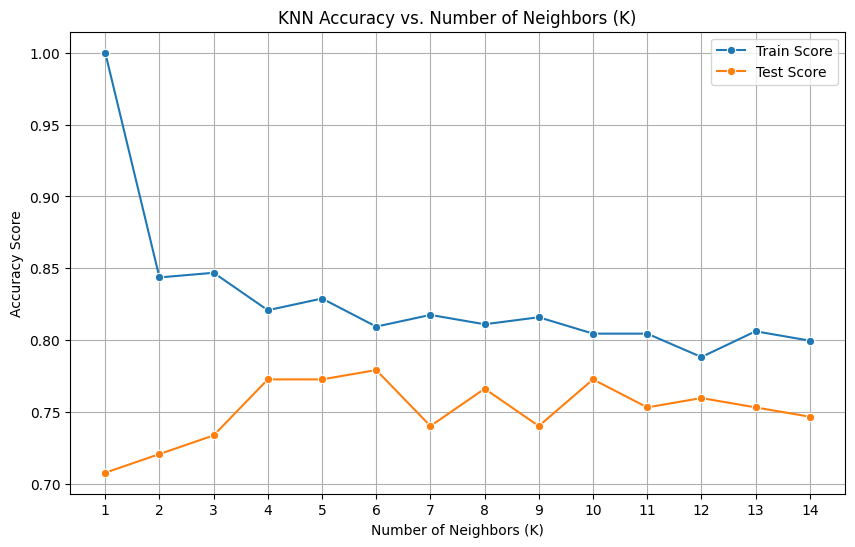

In [10]:
plt.figure(figsize=(10,6))
sns.lineplot(x=range(1,15), y=train_score, marker='o', label='Train Score')
sns.lineplot(x=range(1,15), y=test_score, marker='o', label='Test Score')

plt.title('KNN Accuracy vs. Number of Neighbors (K)')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy Score')
plt.xticks(range(1,15)) 
plt.grid(True)
plt.show()

In [11]:
knn_final=KNeighborsClassifier(n_neighbors=5)
knn_final.fit(X_train_scaled,y_train)

y_pred=knn_final.predict(X_test_scaled)


In [12]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.80      0.86      0.83       100
           1       0.70      0.61      0.65        54

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.74       154
weighted avg       0.77      0.77      0.77       154



In [13]:
conf_matrix=confusion_matrix(y_test,y_pred)
conf_matrix

array([[86, 14],
       [21, 33]])

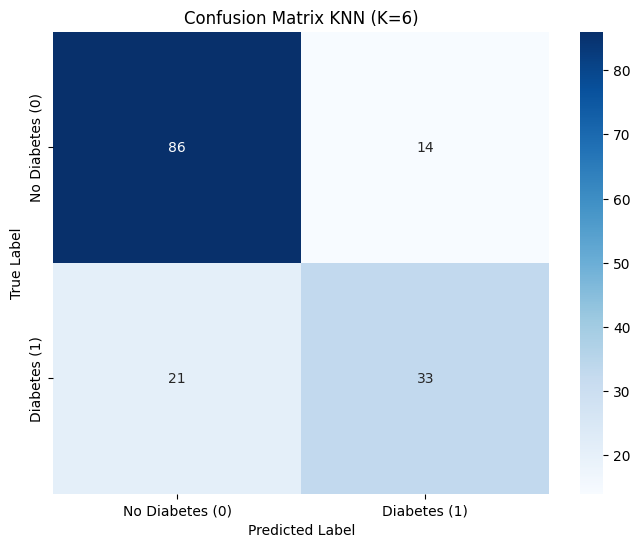

In [14]:
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Diabetes (0)', 'Diabetes (1)'], 
            yticklabels=['No Diabetes (0)', 'Diabetes (1)'])
plt.title('Confusion Matrix KNN (K=6)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

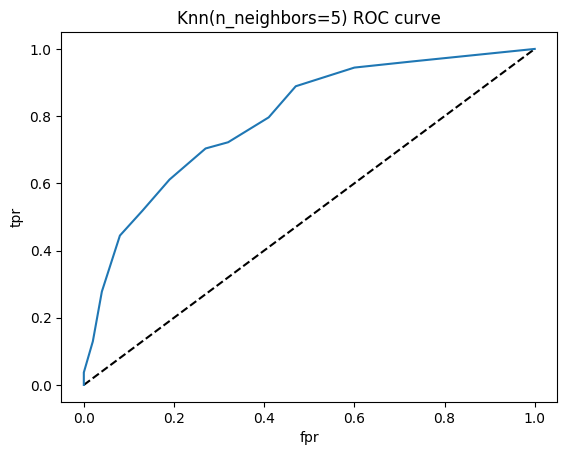

In [15]:
y_pred_proba=knn.predict_proba(X_test_scaled)[:,1]
fpr,tpr,thresholds=roc_curve(y_test,y_pred_proba)
plt.plot([0,1],[0,1],'k--')
plt.plot(fpr,tpr, label='Knn')
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.title('Knn(n_neighbors=5) ROC curve')
plt.show()

In [16]:
roc_auc_score(y_test,y_pred_proba)

0.793425925925926

In [17]:
param_grid={'n_neighbors':np.arange(1,50)}
knn=KNeighborsClassifier()
knn_cv=GridSearchCV(knn,param_grid,cv=5,scoring='f1')
knn_cv.fit(X_train_scaled,y_train)
print("Best Score:" + str(knn_cv.best_score_))
print("Best Parameters: " + str(knn_cv.best_params_))
y_pred = knn_cv.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

Best Score:0.6492207598043006
Best Parameters: {'n_neighbors': np.int64(19)}
              precision    recall  f1-score   support

           0       0.79      0.88      0.83       100
           1       0.72      0.57      0.64        54

    accuracy                           0.77       154
   macro avg       0.76      0.73      0.74       154
weighted avg       0.77      0.77      0.77       154

